# Step 1: Verify Annotation Component Quality

Before attempting any fiber connection, verify that annotation components themselves are high-quality.

**Key questions:**
- Does each annotation component correspond to exactly one GT fiber? (1:1 ideal)
- Are there **merged** components (one component spanning multiple GT fibers)?
- Are there **fragmented** GT fibers (one GT fiber split across many annotation components)?

**Output:** Component purity statistics to confirm annotations are a valid starting point.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io
from skimage.measure import label, regionprops
from scipy import ndimage
import pandas as pd
from neural_reconstruction.dataset import DatasetLoader, SampleFiles
DATA_DIR = Path('../../data_0331')
loader = DatasetLoader(DATA_DIR)
samples = loader.load_samples()
print(f'Total GT samples: {len(samples)}')

Total GT samples: 48


## Helper Functions

In [34]:
def load_sample(sample_info: SampleFiles):
    """Load annotation, label (GT), and mask for a sample."""
    annotation = io.imread(sample_info.annotation_path)
    label_img   = io.imread(sample_info.label_path)
    mask        = io.imread(sample_info.mask_path)

    # Reduce to 2D
    if annotation.ndim == 3: annotation = annotation[..., 0]
    if label_img.ndim == 3:  label_img  = label_img[..., 0]
    if mask.ndim == 3:       mask       = mask[..., 0]

    # Binarize
    annotation_bin = (annotation > 127).astype(np.uint8)
    label_bin      = (label_img  > 127).astype(np.uint8)
    mask_bin       = (mask       > 127).astype(np.uint8)

    return annotation_bin, label_bin, mask_bin


def get_components(binary_img, min_area=10):
    """Label connected components, filter by min_area."""
    labeled = label(binary_img, connectivity=1)
    for p in regionprops(labeled):
        if p.area < min_area:
            labeled[labeled == p.label] = 0
    labeled, _ = ndimage.label(labeled > 0)
    return labeled


def analyze_sample(sample_info: SampleFiles, min_area=10):
    """
    Compute purity and coverage metrics for one sample.

    Purity (annotation component perspective):
      For each annotation component, what fraction of its pixels
      belong to the single dominant GT fiber?
      purity=1.0 -> pure (only one GT fiber)
      purity<0.8 -> merged (spans multiple GT fibers)

    Fragmentation (GT fiber perspective):
      How many annotation components cover each GT fiber?
      0 -> uncovered, 1 -> ideal, >=2 -> fragmented (needs connection)
    """
    annotation_bin, label_bin, mask_bin = load_sample(sample_info)

    annotation_masked = annotation_bin 
    label_masked      = label_bin      

    annot_labeled = get_components(annotation_masked, min_area=min_area)
    gt_labeled    = get_components(label_masked,      min_area=min_area)

    n_annot = annot_labeled.max()
    n_gt    = gt_labeled.max()

    # Annotation component purity
    purity_per_annot = []
    gt_ids_per_annot = []

    for a_id in range(1, n_annot + 1):
        a_mask = annot_labeled == a_id
        gt_under = gt_labeled[a_mask]
        gt_under = gt_under[gt_under > 0]

        if len(gt_under) == 0:
            purity_per_annot.append(np.nan)  # no GT overlap
            gt_ids_per_annot.append(set())
            continue

        unique_gt, counts = np.unique(gt_under, return_counts=True)
        purity = counts.max() / len(gt_under)
        purity_per_annot.append(purity)
        gt_ids_per_annot.append(set(unique_gt.tolist()))

    # GT fiber fragmentation and coverage
    annot_ids_per_gt = []
    coverage_per_gt  = []

    for g_id in range(1, n_gt + 1):
        g_mask = gt_labeled == g_id
        annot_under = annot_labeled[g_mask]
        annot_fg    = annot_under[annot_under > 0]

        annot_ids_per_gt.append(set(np.unique(annot_fg).tolist()))
        coverage_per_gt.append(len(annot_fg) / g_mask.sum())

    return {
        'sample_id': sample_info,
        'n_annot_components': n_annot,
        'n_gt_fibers': n_gt,
        'purity_per_annot': purity_per_annot,
        'gt_ids_per_annot': gt_ids_per_annot,
        'annot_ids_per_gt': annot_ids_per_gt,
        'coverage_per_gt': coverage_per_gt,
        'annot_labeled': annot_labeled,
        'gt_labeled': gt_labeled,
        'annotation_bin': annotation_bin * mask_bin,
        'label_bin': label_bin * mask_bin,
    }

## Single Sample Deep Dive

Start with one sample to understand the data before batch analysis.

In [35]:
result = analyze_sample(samples[1])

n_annot = result['n_annot_components']
n_gt    = result['n_gt_fibers']

purity_vals = [p for p in result['purity_per_annot'] if not np.isnan(p)]
n_no_gt     = sum(np.isnan(p) for p in result['purity_per_annot'])
n_annot_per_gt = [len(s) for s in result['annot_ids_per_gt']]
coverage    = result['coverage_per_gt']

print(f"Sample: {result['sample_id']}")
print(f"  Annotation components : {n_annot}")
print(f"  GT fibers             : {n_gt}")
print(f"  Ratio (annot/GT)      : {n_annot / max(n_gt, 1):.2f}  (ideal = 1.0)")

print(f"\n--- Annotation Component Purity ---")
print(f"  No GT overlap : {n_no_gt} components")
print(f"  Mean purity   : {np.mean(purity_vals):.3f}")
print(f"  Median purity : {np.median(purity_vals):.3f}")
print(f"  Min purity    : {np.min(purity_vals):.3f}")
print(f"  Purity < 0.8  : {sum(p < 0.8 for p in purity_vals)} components  <- potentially merged")
print(f"  Purity == 1.0 : {sum(p == 1.0 for p in purity_vals)} components  <- pure")

print(f"\n--- GT Fiber Coverage ---")
print(f"  Mean annot components per GT fiber : {np.mean(n_annot_per_gt):.2f}")
print(f"  Max annot components per GT fiber  : {max(n_annot_per_gt)}")
print(f"  GT fibers with 0 annot coverage    : {sum(n == 0 for n in n_annot_per_gt)}  <- uncovered")
print(f"  GT fibers with 1 annot component   : {sum(n == 1 for n in n_annot_per_gt)}")
print(f"  GT fibers with >=2 annot components: {sum(n >= 2 for n in n_annot_per_gt)}  <- fragmented")
print(f"  Mean pixel coverage of GT fibers   : {np.mean(coverage):.3f}")

Sample: SampleFiles(sample_id='S1140-2_b', image_path=PosixPath('../../data_0331/S1140-2_b/image.png'), mask_path=PosixPath('../../data_0331/S1140-2_b/mask.png'), annotation_path=PosixPath('../../data_0331/S1140-2_b/weka.png'), label_path=PosixPath('../../data_0331/S1140-2_b/label.png'))
  Annotation components : 593
  GT fibers             : 107
  Ratio (annot/GT)      : 5.54  (ideal = 1.0)

--- Annotation Component Purity ---
  No GT overlap : 0 components
  Mean purity   : 0.999
  Median purity : 1.000
  Min purity    : 0.818
  Purity < 0.8  : 0 components  <- potentially merged
  Purity == 1.0 : 591 components  <- pure

--- GT Fiber Coverage ---
  Mean annot components per GT fiber : 5.56
  Max annot components per GT fiber  : 62
  GT fibers with 0 annot coverage    : 8  <- uncovered
  GT fibers with 1 annot component   : 23
  GT fibers with >=2 annot components: 76  <- fragmented
  Mean pixel coverage of GT fibers   : 0.223


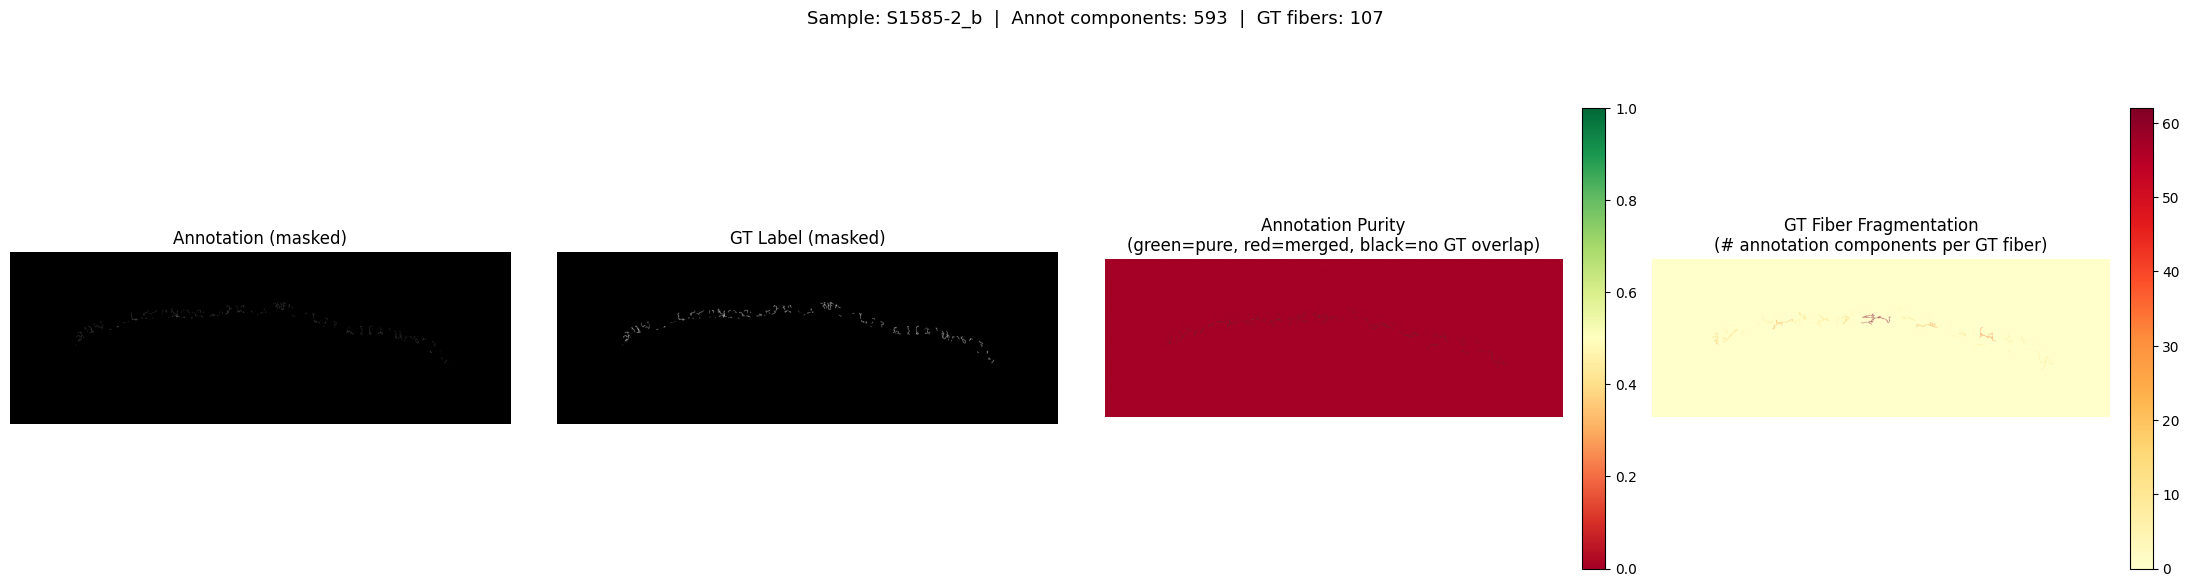

In [36]:
# Visualize: purity map and fragmentation map
annot_labeled = result['annot_labeled']
gt_labeled    = result['gt_labeled']

# Purity map: each annotation component colored by purity score
purity_map = np.zeros(annot_labeled.shape, dtype=float)
for a_id, p in enumerate(result['purity_per_annot'], start=1):
    purity_map[annot_labeled == a_id] = p if not np.isnan(p) else -0.1

# Fragmentation map: each GT fiber colored by #annotation components
frag_map = np.zeros(gt_labeled.shape, dtype=float)
for g_id, n in enumerate(n_annot_per_gt, start=1):
    frag_map[gt_labeled == g_id] = n

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(result['annotation_bin'], cmap='gray')
axes[0].set_title('Annotation (masked)')
axes[0].axis('off')

axes[1].imshow(result['label_bin'], cmap='gray')
axes[1].set_title('GT Label (masked)')
axes[1].axis('off')

im2 = axes[2].imshow(purity_map, cmap='RdYlGn', vmin=0, vmax=1)
axes[2].set_title('Annotation Purity\n(green=pure, red=merged, black=no GT overlap)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

max_frag = max(n_annot_per_gt) if n_annot_per_gt else 1
im3 = axes[3].imshow(frag_map, cmap='YlOrRd', vmin=0, vmax=max(max_frag, 3))
axes[3].set_title('GT Fiber Fragmentation\n(# annotation components per GT fiber)')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle(f'Sample: {SAMPLE}  |  Annot components: {n_annot}  |  GT fibers: {n_gt}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

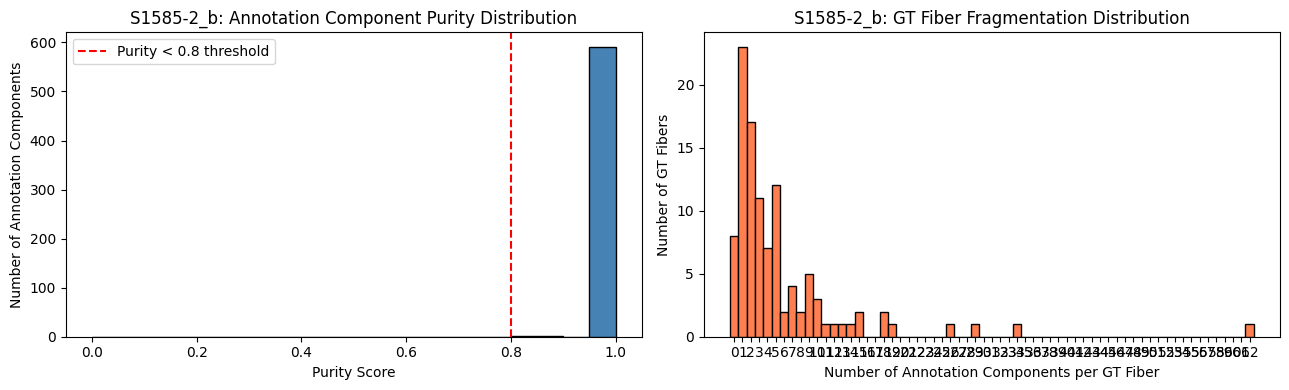

In [37]:
# Distribution histograms for single sample
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(purity_vals, bins=20, range=(0, 1), edgecolor='black', color='steelblue')
axes[0].axvline(0.8, color='red', linestyle='--', label='Purity < 0.8 threshold')
axes[0].set_xlabel('Purity Score')
axes[0].set_ylabel('Number of Annotation Components')
axes[0].set_title(f'{SAMPLE}: Annotation Component Purity Distribution')
axes[0].legend()

axes[1].hist(n_annot_per_gt, bins=range(0, max(n_annot_per_gt) + 2),
             align='left', edgecolor='black', color='coral')
axes[1].set_xlabel('Number of Annotation Components per GT Fiber')
axes[1].set_ylabel('Number of GT Fibers')
axes[1].set_title(f'{SAMPLE}: GT Fiber Fragmentation Distribution')
axes[1].set_xticks(range(0, max(n_annot_per_gt) + 1))

plt.tight_layout()
plt.show()

## Batch Analysis: All GT Samples

In [38]:
all_results = {}
for sin in samples:
    try:
        r = analyze_sample(sin)
        all_results[sin.sample_id] = r
        print(f"OK  {sin.sample_id}:  annot={r['n_annot_components']:3d}  gt={r['n_gt_fibers']:3d}  "
              f"ratio={r['n_annot_components']/max(r['n_gt_fibers'],1):.2f}")
    except Exception as e:
        print(f"ERR {sin.sample_id}: {e}")

OK  S1140-2_a:  annot=540  gt= 98  ratio=5.51
OK  S1140-2_b:  annot=593  gt=107  ratio=5.54
OK  S1196-2_a:  annot=250  gt= 43  ratio=5.81
OK  S1196-2_b:  annot=276  gt= 33  ratio=8.36
OK  S1278-2_a:  annot=930  gt= 92  ratio=10.11
OK  S1278-2_b:  annot=741  gt= 82  ratio=9.04
OK  S1313-2_a:  annot=450  gt=114  ratio=3.95
OK  S1313-2_b:  annot=438  gt= 84  ratio=5.21
OK  S1401-2_a:  annot=590  gt= 74  ratio=7.97
OK  S1401-2_b:  annot=564  gt= 88  ratio=6.41
OK  S1430-2_a:  annot=312  gt=101  ratio=3.09
OK  S1430-2_b:  annot=405  gt= 99  ratio=4.09
OK  S1475-2_a:  annot=230  gt= 38  ratio=6.05
OK  S1475-2_b:  annot=302  gt= 42  ratio=7.19
OK  S1494-2_a:  annot=583  gt= 66  ratio=8.83
OK  S1494-2_b:  annot=603  gt=100  ratio=6.03
OK  S1571-2_a:  annot=1073  gt=142  ratio=7.56
OK  S1571-2_b:  annot=869  gt=129  ratio=6.74
OK  S1585-2_a:  annot=477  gt= 86  ratio=5.55
OK  S1585-2_b:  annot=569  gt= 99  ratio=5.75
OK  S1616-2_a:  annot=383  gt= 50  ratio=7.66
OK  S1616-2_b:  annot=658  gt= 9

In [39]:
# Build summary DataFrame
rows = []
for sid, r in all_results.items():
    purity_v      = [p for p in r['purity_per_annot'] if not np.isnan(p)]
    frag_v        = [len(s) for s in r['annot_ids_per_gt']]
    coverage_v    = r['coverage_per_gt']

    rows.append({
        'sample': sid,
        'n_annot': r['n_annot_components'],
        'n_gt': r['n_gt_fibers'],
        'annot_gt_ratio': r['n_annot_components'] / max(r['n_gt_fibers'], 1),
        # Purity (annotation component perspective)
        'purity_mean':   np.mean(purity_v)   if purity_v else np.nan,
        'purity_median': np.median(purity_v) if purity_v else np.nan,
        'purity_min':    np.min(purity_v)    if purity_v else np.nan,
        'n_merged':  sum(p < 0.8 for p in purity_v),  # spans >1 GT fiber
        'n_pure':    sum(p == 1.0 for p in purity_v),
        'n_no_gt':   sum(np.isnan(p) for p in r['purity_per_annot']),
        # Fragmentation (GT fiber perspective)
        'frag_mean': np.mean(frag_v) if frag_v else np.nan,
        'frag_max':  max(frag_v)     if frag_v else 0,
        'n_gt_uncovered':  sum(n == 0 for n in frag_v),
        'n_gt_single':     sum(n == 1 for n in frag_v),
        'n_gt_fragmented': sum(n >= 2 for n in frag_v),
        'coverage_mean': np.mean(coverage_v) if coverage_v else np.nan,
    })

df = pd.DataFrame(rows).set_index('sample')

float_cols = ['annot_gt_ratio', 'purity_mean', 'purity_median', 'purity_min', 'frag_mean', 'coverage_mean']
df_display = df.copy()
df_display[float_cols] = df_display[float_cols].round(3)
df_display

,n_annot,n_gt,annot_gt_ratio,purity_mean,purity_median,purity_min,n_merged,n_pure,n_no_gt,frag_mean,frag_max,n_gt_uncovered,n_gt_single,n_gt_fragmented,coverage_mean
sample,,,,,,,,,,,,,,,
S1140-2_a,540,98,5.510,1.000,1.0,0.905,0,539,0,5.520,46,13,17,68,0.259
S1140-2_b,593,107,5.542,0.999,1.0,0.818,0,591,0,5.561,62,8,23,76,0.223
S1196-2_a,250,43,5.814,1.000,1.0,1.000,0,249,1,5.791,19,0,6,37,0.757
S1196-2_b,276,33,8.364,1.000,1.0,1.000,0,276,0,8.364,36,0,0,33,0.623
S1278-2_a,930,92,10.109,0.997,1.0,0.514,7,920,0,10.228,56,0,4,88,0.696
S1278-2_b,741,82,9.037,0.997,1.0,0.513,5,730,1,9.146,56,0,6,76,0.534
S1313-2_a,450,114,3.947,1.000,1.0,1.000,0,450,0,3.947,35,16,26,72,0.240
S1313-2_b,438,84,5.214,0.999,1.0,0.767,1,436,0,5.238,21,9,13,62,0.224
S1401-2_a,590,74,7.973,0.998,1.0,0.649,3,584,0,8.054,38,0,2,72,0.628


In [40]:
# Aggregate summary
print("=" * 55)
print("OVERALL SUMMARY ACROSS ALL SAMPLES")
print("=" * 55)
print(f"Samples analyzed           : {len(df)}")
print()
print("Annotation components vs GT fibers:")
print(f"  Total annotation components : {df['n_annot'].sum()}")
print(f"  Total GT fibers             : {df['n_gt'].sum()}")
print(f"  Mean ratio (annot/GT)       : {df['annot_gt_ratio'].mean():.2f}  (ideal = 1.0)")
print()
print("Purity (annotation component perspective):")
print(f"  Mean purity across samples  : {df['purity_mean'].mean():.3f}")
print(f"  Total merged components     : {df['n_merged'].sum()}  (purity < 0.8)")
print(f"  Total pure components       : {df['n_pure'].sum()}  (purity = 1.0)")
print(f"  Total no-GT-overlap         : {df['n_no_gt'].sum()}")
print()
print("Fragmentation (GT fiber perspective):")
print(f"  Mean annot components per GT fiber : {df['frag_mean'].mean():.2f}")
print(f"  Total uncovered GT fibers   : {df['n_gt_uncovered'].sum()}")
print(f"  Total fragmented GT fibers  : {df['n_gt_fragmented'].sum()}  (>=2 components)")
print(f"  Mean GT pixel coverage      : {df['coverage_mean'].mean():.3f}")

OVERALL SUMMARY ACROSS ALL SAMPLES
Samples analyzed           : 48

Annotation components vs GT fibers:
  Total annotation components : 26764
  Total GT fibers             : 4130
  Mean ratio (annot/GT)       : 6.70  (ideal = 1.0)

Purity (annotation component perspective):
  Mean purity across samples  : 0.998
  Total merged components     : 121  (purity < 0.8)
  Total pure components       : 26521  (purity = 1.0)
  Total no-GT-overlap         : 4

Fragmentation (GT fiber perspective):
  Mean annot components per GT fiber : 6.75
  Total uncovered GT fibers   : 103
  Total fragmented GT fibers  : 3455  (>=2 components)
  Mean GT pixel coverage      : 0.579


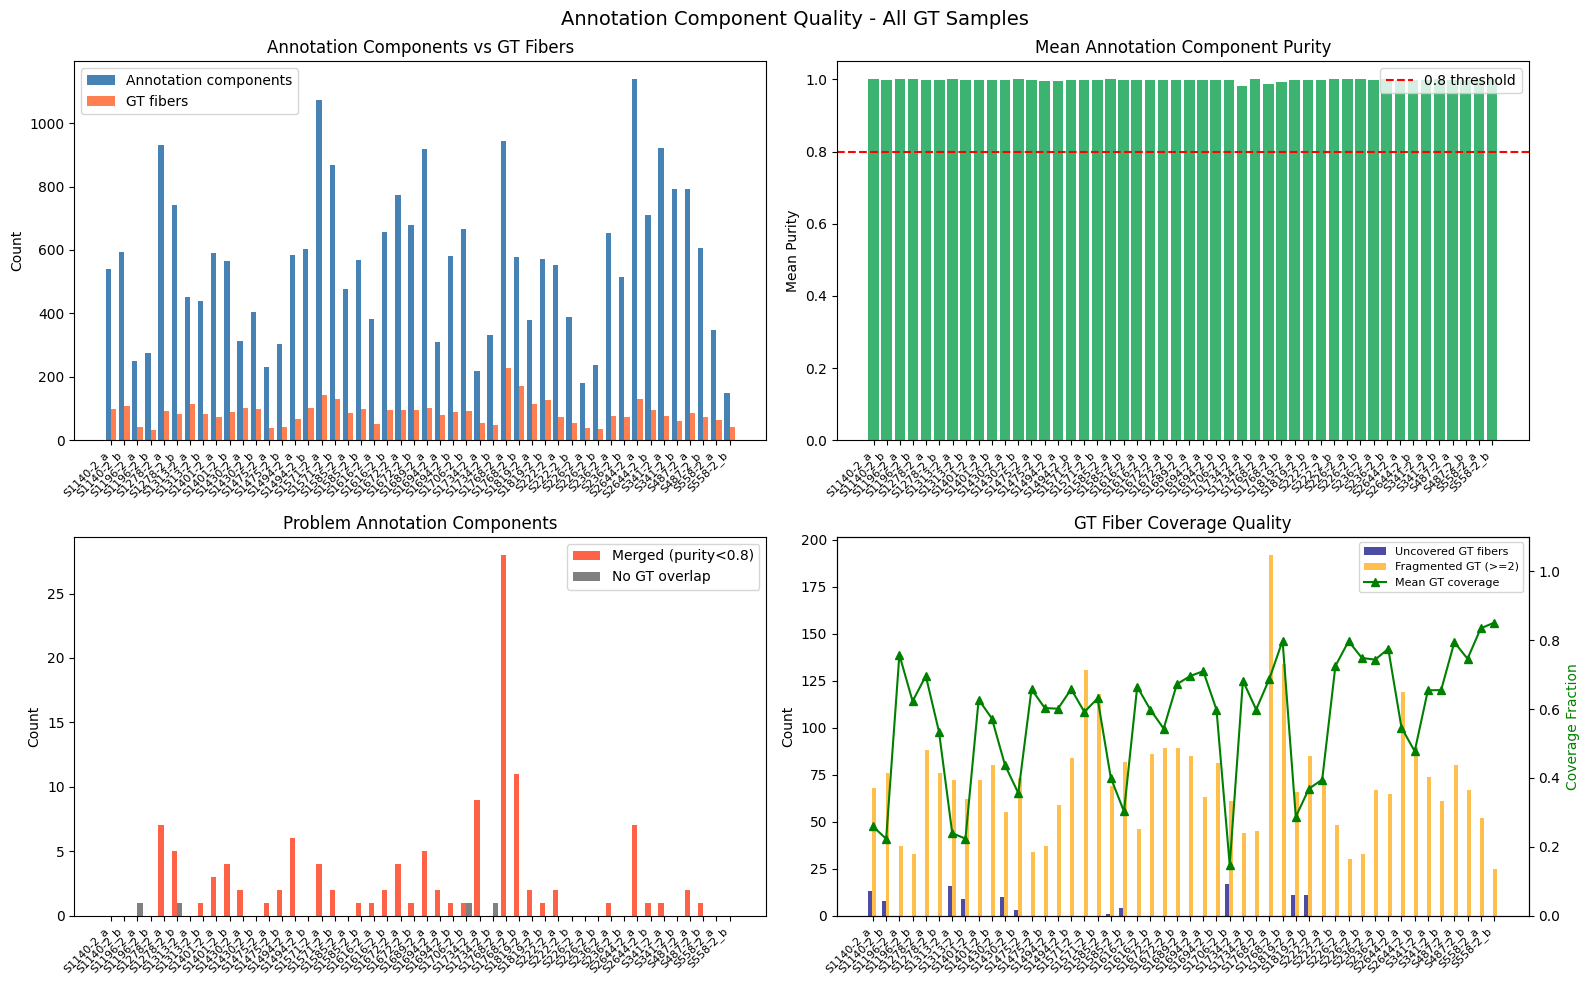

In [41]:
# Batch visualization
samples = df.index.tolist()
x = np.arange(len(samples))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Annotation components vs GT fibers
ax = axes[0, 0]
ax.bar(x - 0.2, df['n_annot'], width=0.4, label='Annotation components', color='steelblue')
ax.bar(x + 0.2, df['n_gt'],    width=0.4, label='GT fibers',             color='coral')
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Annotation Components vs GT Fibers')
ax.legend()

# 2. Mean purity per sample
ax = axes[0, 1]
ax.bar(x, df['purity_mean'], color='mediumseagreen')
ax.axhline(0.8, color='red', linestyle='--', label='0.8 threshold')
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Mean Purity')
ax.set_title('Mean Annotation Component Purity')
ax.legend()

# 3. Merged and no-GT-overlap components
ax = axes[1, 0]
ax.bar(x - 0.2, df['n_merged'], width=0.4, label='Merged (purity<0.8)', color='tomato')
ax.bar(x + 0.2, df['n_no_gt'],  width=0.4, label='No GT overlap',       color='gray')
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Problem Annotation Components')
ax.legend()

# 4. GT fragmentation and coverage
ax = axes[1, 1]
ax2 = ax.twinx()
ax.bar(x - 0.2, df['n_gt_uncovered'],  width=0.3, label='Uncovered GT fibers',    color='navy',   alpha=0.7)
ax.bar(x + 0.1, df['n_gt_fragmented'], width=0.3, label='Fragmented GT (>=2)',    color='orange', alpha=0.7)
ax2.plot(x, df['coverage_mean'], 'g^-', label='Mean GT coverage', markersize=6)
ax.set_xticks(x)
ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax2.set_ylabel('Coverage Fraction', color='green')
ax2.set_ylim(0, 1.1)
ax.set_title('GT Fiber Coverage Quality')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Annotation Component Quality - All GT Samples', fontsize=14)
plt.tight_layout()
plt.show()

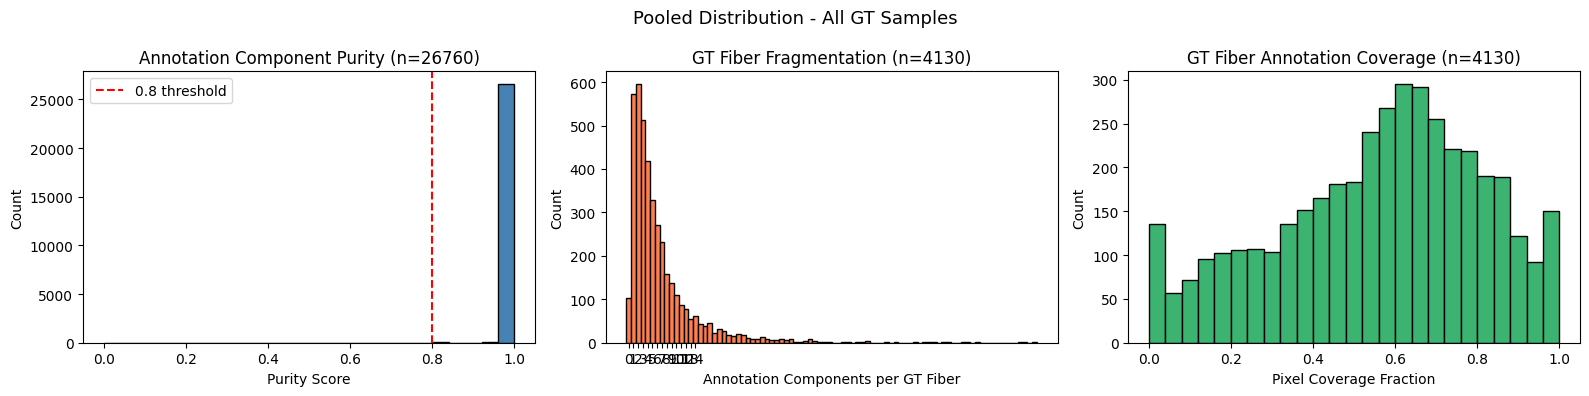

Purity < 0.8   : 121/26760 = 0.5%
GT uncovered   : 103/4130 = 2.5%
GT fragmented  : 3455/4130 = 83.7%


In [42]:
# Pooled distributions across all samples
all_purity = []
all_frag   = []
all_cov    = []

for r in all_results.values():
    all_purity.extend([p for p in r['purity_per_annot'] if not np.isnan(p)])
    all_frag.extend([len(s) for s in r['annot_ids_per_gt']])
    all_cov.extend(r['coverage_per_gt'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(all_purity, bins=25, range=(0, 1), edgecolor='black', color='steelblue')
axes[0].axvline(0.8, color='red', linestyle='--', label='0.8 threshold')
axes[0].set_xlabel('Purity Score')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Annotation Component Purity (n={len(all_purity)})')
axes[0].legend()

max_f = max(all_frag) if all_frag else 1
axes[1].hist(all_frag, bins=range(0, max_f + 2), align='left', edgecolor='black', color='coral')
axes[1].set_xlabel('Annotation Components per GT Fiber')
axes[1].set_ylabel('Count')
axes[1].set_title(f'GT Fiber Fragmentation (n={len(all_frag)})')
axes[1].set_xticks(range(0, min(max_f + 1, 15)))

axes[2].hist(all_cov, bins=25, range=(0, 1), edgecolor='black', color='mediumseagreen')
axes[2].set_xlabel('Pixel Coverage Fraction')
axes[2].set_ylabel('Count')
axes[2].set_title(f'GT Fiber Annotation Coverage (n={len(all_cov)})')

plt.suptitle('Pooled Distribution - All GT Samples', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Purity < 0.8   : {sum(p < 0.8 for p in all_purity)}/{len(all_purity)} = "
      f"{sum(p<0.8 for p in all_purity)/len(all_purity)*100:.1f}%")
print(f"GT uncovered   : {sum(f==0 for f in all_frag)}/{len(all_frag)} = "
      f"{sum(f==0 for f in all_frag)/len(all_frag)*100:.1f}%")
print(f"GT fragmented  : {sum(f>=2 for f in all_frag)}/{len(all_frag)} = "
      f"{sum(f>=2 for f in all_frag)/len(all_frag)*100:.1f}%")

## Conclusion

Fill in after running the analysis:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean purity | — | How often one annotation component = one GT fiber |
| Merged components (purity<0.8) | — | Risk: annotation spans multiple GT fibers |
| GT fibers uncovered | — | Fibers completely missed by annotations |
| GT fibers fragmented (>=2) | — | Fibers needing connection in Step 2+ |
| Mean GT pixel coverage | — | Fraction of GT pixels annotated |

**Verdict:** Are annotation components a valid starting point for Step 2 (multi-source Dijkstra)?